In [1]:
# Imports math library
import numpy as np
# Imports plotting library
import matplotlib.pyplot as plt

In [2]:
# Define the Rectified Linear Unit (ReLU) function
def ReLU(preactivation):
  activation = preactivation.clip(0.0)
  return activation

In [3]:
# Define a shallow neural network with, one input, one output, and three hidden units
def shallow_1_1_3(x, activation_fn, phi_0,phi_1,phi_2,phi_3, theta_10, theta_11, theta_20, theta_21, theta_30, theta_31):
  # Initial lines
  pre_1 = theta_10 + theta_11 * x
  pre_2 = theta_20 + theta_21 * x
  pre_3 = theta_30 + theta_31 * x
  # Activation functions
  act_1 = activation_fn(pre_1)
  act_2 = activation_fn(pre_2)
  act_3 = activation_fn(pre_3)
  # Weight activations
  w_act_1 = phi_1 * act_1
  w_act_2 = phi_2 * act_2
  w_act_3 = phi_3 * act_3
  # Combine weighted activation and add y offset
  y = phi_0 + w_act_1 + w_act_2 + w_act_3
  # Return everything we have calculated
  return y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3

In [4]:
# # Plot the shallow neural network.  We'll assume input in is range [-1,1] and output [-1,1]
def plot_neural(x, y):
  fig, ax = plt.subplots()
  ax.plot(x.T,y.T)
  ax.set_xlabel('Input'); ax.set_ylabel('Output')
  ax.set_xlim([-1,1]);ax.set_ylim([-1,1])
  ax.set_aspect(1.0)
  plt.show()

Let's define a network.  We'll just consider the inputs and outputs over the range [-1,1].

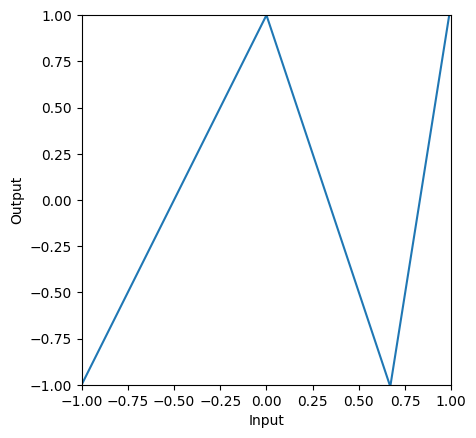

In [5]:
# Now lets define some parameters and run the first neural network
n1_theta_10 = 0.0   ; n1_theta_11 = -1.0
n1_theta_20 = 0     ; n1_theta_21 = 1.0
n1_theta_30 = -0.67 ; n1_theta_31 =  1.0
n1_phi_0 = 1.0; n1_phi_1 = -2.0; n1_phi_2 = -3.0; n1_phi_3 = 9.3

# Define a range of input values
n1_in = np.arange(-1,1,0.01).reshape([1,-1])

# We run the neural network for each of these input values
n1_out, *_ = shallow_1_1_3(n1_in, ReLU, n1_phi_0, n1_phi_1, n1_phi_2, n1_phi_3, n1_theta_10, n1_theta_11, n1_theta_20, n1_theta_21, n1_theta_30, n1_theta_31)
# And then plot it
plot_neural(n1_in, n1_out)

Now we'll define the same neural network, but this time, we will  use matrix form as in equation 4.15.  When you get this right, it will draw the same plot as above.

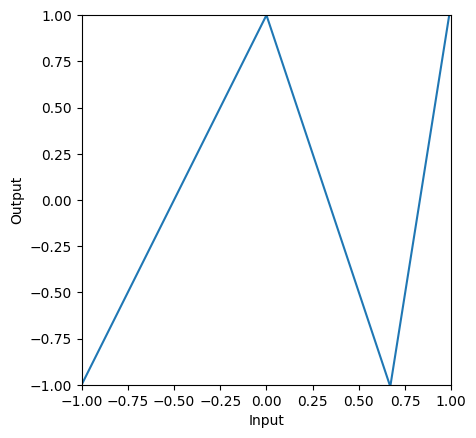

In [7]:
beta_0 = np.zeros((3,1))
Omega_0 = np.zeros((3,1))
beta_1 = np.zeros((1,1))
Omega_1 = np.zeros((1,3))

# TODO Fill in the values of the beta and Omega matrices with the n1_theta and n1_phi parameters that define the network above
# !!! NOTE THAT MATRICES ARE CONVENTIONALLY INDEXED WITH a_11 IN THE TOP LEFT CORNER, BUT NDARRAYS START AT [0,0]
# To get you started I've filled in a couple:

beta_0 = np.zeros((3,1))
Omega_0 = np.zeros((3,1))
beta_1 = np.zeros((1,1))
Omega_1 = np.zeros((1,3))

# ── Capa oculta: biases β₀ (los θᵢ₀) ──
beta_0[0,0] = n1_theta_10   # θ₁₀ =  0.0
beta_0[1,0] = n1_theta_20   # θ₂₀ =  0.0
beta_0[2,0] = n1_theta_30   # θ₃₀ = -0.67

# ── Capa oculta: pesos Ω₀ (los θᵢ₁) ──
Omega_0[0,0] = n1_theta_11  # θ₁₁ = -1.0
Omega_0[1,0] = n1_theta_21  # θ₂₁ =  1.0
Omega_0[2,0] = n1_theta_31  # θ₃₁ =  1.0

# ── Capa de salida: bias β₁ (el φ₀) ──
beta_1[0,0] = n1_phi_0      # φ₀ =  1.0

# ── Capa de salida: pesos Ω₁ (los φᵢ) ──
Omega_1[0,0] = n1_phi_1     # φ₁ = -2.0
Omega_1[0,1] = n1_phi_2     # φ₂ = -3.0
Omega_1[0,2] = n1_phi_3     # φ₃ =  9.3

# ── Forward pass (no tocar) ──
n_data    = n1_in.size
n_dim_in  = 1
n1_in_mat = np.reshape(n1_in, (n_dim_in, n_data))

h1     = ReLU(beta_0 + np.matmul(Omega_0, n1_in_mat))
n1_out = beta_1 + np.matmul(Omega_1, h1)

plot_neural(n1_in, n1_out)

Now we'll feed the output of the first network into the second one.

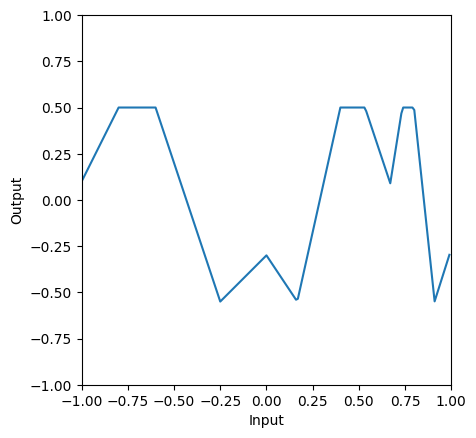

In [8]:
# Now lets define some parameters and run the second neural network
n2_theta_10 =  -0.6 ; n2_theta_11 = -1.0
n2_theta_20 =  0.2  ; n2_theta_21 = 1.0
n2_theta_30 =  -0.5  ; n2_theta_31 =  1.0
n2_phi_0 = 0.5; n2_phi_1 = -1.0; n2_phi_2 = -1.5; n2_phi_3 = 2.0

# Define a range of input values
n2_in = np.arange(-1,1,0.01)

# We run the second neural network on the output of the first network
n2_out, *_ = \
    shallow_1_1_3(n1_out, ReLU, n2_phi_0, n2_phi_1, n2_phi_2, n2_phi_3, n2_theta_10, n2_theta_11, n2_theta_20, n2_theta_21, n2_theta_30, n2_theta_31)
# And then plot it
plot_neural(n1_in, n2_out)

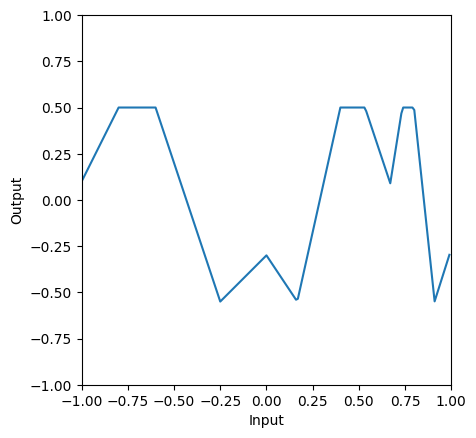

In [9]:
beta_0 = np.zeros((3,1))
Omega_0 = np.zeros((3,1))
beta_1 = np.zeros((3,1))
Omega_1 = np.zeros((3,3))
beta_2 = np.zeros((1,1))
Omega_2 = np.zeros((1,3))

# TODO Fill in the values of the beta and Omega matrices for the n1_theta, n1_phi, n2_theta, and n2_phi parameters
# that define the composition of the two networks above (see eqn 4.5 for Omega1 and beta1 albeit in different notation)
# !!! NOTE THAT MATRICES ARE CONVENTIONALLY INDEXED WITH a_11 IN THE TOP LEFT CORNER, BUT NDARRAYS START AT [0,0] SO EVERYTHING IS OFFSET
# To get you started I've filled in a few:

# ── CAPA 0: Red 1 — capa oculta ──
beta_0[0,0] = n1_theta_10   # θ₁₀ =  0.0
beta_0[1,0] = n1_theta_20   # θ₂₀ =  0.0
beta_0[2,0] = n1_theta_30   # θ₃₀ = -0.67

Omega_0[0,0] = n1_theta_11  # θ₁₁ = -1.0
Omega_0[1,0] = n1_theta_21  # θ₂₁ =  1.0
Omega_0[2,0] = n1_theta_31  # θ₃₁ =  1.0

# ── CAPA 1: Red 2 — capa oculta (absorbe salida de Red 1) ──
beta_1[0,0] = n2_theta_10 + n2_theta_11 * n1_phi_0
beta_1[1,0] = n2_theta_20 + n2_theta_21 * n1_phi_0
beta_1[2,0] = n2_theta_30 + n2_theta_31 * n1_phi_0

Omega_1[0,0] = n2_theta_11 * n1_phi_1
Omega_1[0,1] = n2_theta_11 * n1_phi_2
Omega_1[0,2] = n2_theta_11 * n1_phi_3

Omega_1[1,0] = n2_theta_21 * n1_phi_1
Omega_1[1,1] = n2_theta_21 * n1_phi_2
Omega_1[1,2] = n2_theta_21 * n1_phi_3

Omega_1[2,0] = n2_theta_31 * n1_phi_1
Omega_1[2,1] = n2_theta_31 * n1_phi_2
Omega_1[2,2] = n2_theta_31 * n1_phi_3

# ── CAPA 2: Red 2 — salida ──
beta_2[0,0] = n2_phi_0      # φ₀ = 0.5

Omega_2[0,0] = n2_phi_1     # φ₁ = -1.0
Omega_2[0,1] = n2_phi_2     # φ₂ = -1.5
Omega_2[0,2] = n2_phi_3     # φ₃ =  2.0

# ── Forward pass (no tocar) ──
n_data    = n1_in.size
n_dim_in  = 1
n1_in_mat = np.reshape(n1_in, (n_dim_in, n_data))

h1     = ReLU(beta_0 + np.matmul(Omega_0, n1_in_mat))
h2     = ReLU(beta_1 + np.matmul(Omega_1, h1))
n1_out = beta_2 + np.matmul(Omega_2, h2)

plot_neural(n1_in, n1_out)

Now let's make a deep network with 3 hidden layers.  It will have $D_i=4$ inputs, $D_1=5$ neurons  in the first layer, $D_2=2$ neurons in the second layer and $D_3=4$ neurons in the third layer, and $D_o = 1$ output.

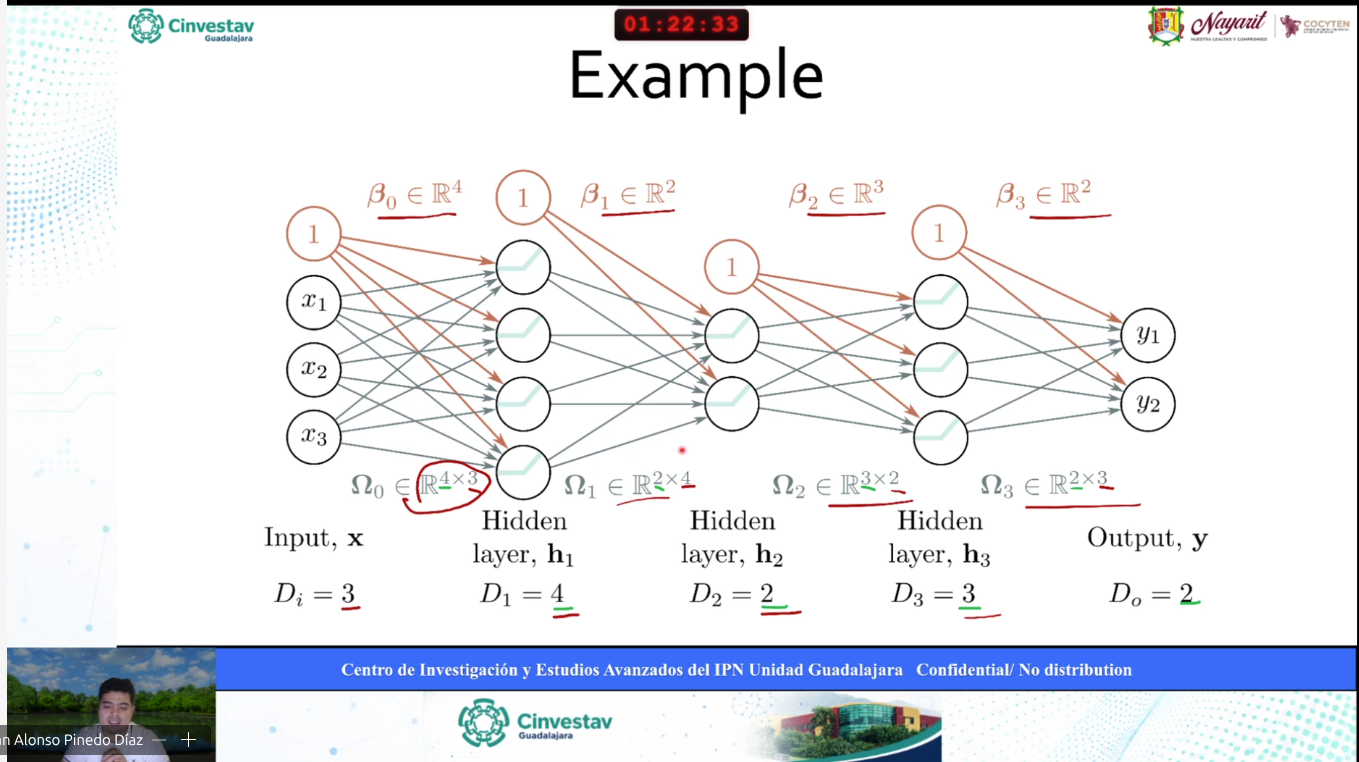

In [10]:

# definir sizes
D_i=4; D_1=5; D_2=2; D_3=4; D_o=1

n_data = 4
x = np.random.normal(size=(D_i, n_data))

# Inicialización con los tamaños correctos
beta_0  = np.random.normal(size=(D_1, 1))      # (5, 1)
Omega_0 = np.random.normal(size=(D_1, D_i))    # (5, 4)

beta_1  = np.random.normal(size=(D_2, 1))      # (2, 1)
Omega_1 = np.random.normal(size=(D_2, D_1))    # (2, 5)

beta_2  = np.random.normal(size=(D_3, 1))      # (4, 1)
Omega_2 = np.random.normal(size=(D_3, D_2))    # (4, 2)

beta_3  = np.random.normal(size=(D_o, 1))      # (1, 1)
Omega_3 = np.random.normal(size=(D_o, D_3))    # (1, 4)

# Forward pass (no se modifica)
h1 = ReLU(beta_0 + np.matmul(Omega_0, x))
h2 = ReLU(beta_1 + np.matmul(Omega_1, h1))
h3 = ReLU(beta_2 + np.matmul(Omega_2, h2))
y  = beta_3 + np.matmul(Omega_3, h3)

if h1.shape[0] is not D_1 or h1.shape[1] is not n_data:
  print("h1 is wrong shape")
if h2.shape[0] is not D_2 or h1.shape[1] is not n_data:
  print("h2 is wrong shape")
if h3.shape[0] is not D_3 or h1.shape[1] is not n_data:
  print("h3 is wrong shape")
if y.shape[0] is not D_o or h1.shape[1] is not n_data:
  print("Output is wrong shape")

print("Input data points")
print(x)
print("Output data points")
print(y)

Input data points
[[ 0.60290625  0.10909671 -0.16183606 -0.48050177]
 [ 0.27597965 -0.73177091  0.57254484  1.43586439]
 [ 0.00617507  0.87614179  1.14967311 -0.8844441 ]
 [ 0.34060395  1.0402664  -0.18841747  0.32163279]]
Output data points
[[-1.28399179 -1.31184783 -1.22014639 -1.09819195]]
